In [143]:
# Importing required libraries
import pandas as pd
import numpy as np #convertingcaregoricalvaluesortexttonumbers,whichmodel needs scaling
from sklearn.impute import SimpleImputer #instead of fill na for missing values


# Visualization libraries
import matplotlib.pyplot as plt 
import seaborn as sns 

#sklearnlibraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Handling missing values
from sklearn.impute import SimpleImputer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# EvaluationMetrics
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix,
roc_auc_score,
roc_curve
)

#survivalAnalysis
from lifelines import KaplanMeierFitter
from lifelines import CoxPHFitter #findingfactors

#ignore warnings
import warnings
warnings.filterwarnings('ignore')


In [144]:
# Load Dataset
df = pd.read_csv("Breast Cancer METABRIC.csv")

In [145]:
# Display First 5 Rows
df.head()

,Patient ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,...,Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Sex,3-Gene classifier subtype,Tumor Size,Tumor Stage,Patient's Vital Status
0,MB-0000,75.65,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,No,claudin-low,1.0,Positve,...,Living,Negative,Yes,138.65,Not Recurred,Female,ER-/HER2-,22.0,2.0,Living
1,MB-0002,43.19,Breast Conserving,Breast Cancer,Breast Invasive Ductal Carcinoma,High,No,LumA,1.0,Positve,...,Living,Positive,Yes,83.52,Not Recurred,Female,ER+/HER2- High Prolif,10.0,1.0,Living
2,MB-0005,48.87,Mastectomy,Breast Cancer,Breast Invasive Ductal Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,No,151.28,Recurred,Female,NaN,15.0,2.0,Died of Disease
3,MB-0006,47.68,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,Yes,LumB,1.0,Positve,...,Living,Positive,Yes,162.76,Not Recurred,Female,NaN,25.0,2.0,Living
4,MB-0008,76.97,Mastectomy,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,Yes,LumB,1.0,Positve,...,Deceased,Positive,Yes,18.55,Recurred,Female,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


In [146]:
#dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (2509, 34)


In [147]:
#column names
print(df.columns)

Index(['Patient ID', 'Age at Diagnosis', 'Type of Breast Surgery',
       'Cancer Type', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy',
       'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC',
       'ER Status', 'Neoplasm Histologic Grade',
       'HER2 status measured by SNP6', 'HER2 Status',
       'Tumor Other Histologic Subtype', 'Hormone Therapy',
       'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code',
       'Overall Survival (Months)', 'Overall Survival Status', 'PR Status',
       'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status',
       'Sex', '3-Gene classifier subtype', 'Tumor Size', 'Tumor Stage',
       'Patient's Vital Status'],
      dtype='object')


In [148]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Patient ID                      2509 non-null   object 
 1   Age at Diagnosis                2498 non-null   float64
 2   Type of Breast Surgery          1955 non-null   object 
 3   Cancer Type                     2509 non-null   object 
 4   Cancer Type Detailed            2509 non-null   object 
 5   Cellularity                     1917 non-null   object 
 6   Chemotherapy                    1980 non-null   object 
 7   Pam50 + Claudin-low subtype     1980 non-null   object 
 8   Cohort                          2498 non-null   float64
 9   ER status measured by IHC       2426 non-null   object 
 10  ER Status                       2469 non-null   object 
 11  Neoplasm Histologic Grade       2388 non-null   float64
 12  HER2 status measured by SNP6    19

In [149]:
#check missing values 
print(df.isnull().sum())

Patient ID                          0
Age at Diagnosis                   11
Type of Breast Surgery            554
Cancer Type                         0
Cancer Type Detailed                0
Cellularity                       592
Chemotherapy                      529
Pam50 + Claudin-low subtype       529
Cohort                             11
ER status measured by IHC          83
ER Status                          40
Neoplasm Histologic Grade         121
HER2 status measured by SNP6      529
HER2 Status                       529
Tumor Other Histologic Subtype    135
Hormone Therapy                   529
Inferred Menopausal State         529
Integrative Cluster               529
Primary Tumor Laterality          639
Lymph nodes examined positive     266
Mutation Count                    152
Nottingham prognostic index       222
Oncotree Code                       0
Overall Survival (Months)         528
Overall Survival Status           528
PR Status                         529
Radio Therap

In [150]:
# Statistical Summary of Dataset
df.describe()

,Age at Diagnosis,Cohort,Neoplasm Histologic Grade,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Overall Survival (Months),Relapse Free Status (Months),Tumor Size,Tumor Stage
count,2498.000000,2498.000000,2388.000000,2243.000000,2357.000000,2287.000000,1981.000000,2388.000000,2360.000000,1788.000000
mean,60.420300,2.900320,2.412060,1.950513,5.578702,4.028787,125.244271,108.842487,26.220093,1.713647
std,13.032997,1.962216,0.649363,4.017774,3.967967,1.189092,76.111772,76.519494,15.370883,0.655307
min,21.930000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,50.920000,1.000000,2.000000,0.000000,3.000000,3.048000,60.866667,40.560000,17.000000,1.000000
50%,61.110000,3.000000,3.000000,0.000000,5.000000,4.044000,116.466667,99.095000,22.410000,2.000000
75%,70.000000,4.000000,3.000000,2.000000,7.000000,5.040000,185.133333,167.640000,30.000000,2.000000
max,96.290000,9.000000,3.000000,45.000000,80.000000,7.200000,355.200000,384.210000,182.000000,4.000000


In [151]:
#check duplicates
df.duplicated().sum()

np.int64(0)

In [152]:
# Remove duplicates

df.drop_duplicates(inplace=True)

Remove Unnecessary Columns

Feature Removal Interpretation
The Patient ID column was removed because it is a unique identifier and does not contribute meaningful information for mortality prediction

In [153]:
# Patient ID is unique for each patientand does not contribute to prediction

if "Patient ID" in df.columns:
    df.drop("Patient ID", axis=1,inplace=True)

In [154]:
# Separate Numerical and Categorical Columns

#Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

#categorical columns
cat_cols=df.select_dtypes(include=object).columns

# Display numerical columns
print("Numerical Columns:",len(num_cols))
print(num_cols)

# Display Categorical columns
print("Categorical Columns:", len(cat_cols))
print(cat_cols)


Numerical Columns: 10
Index(['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade',
       'Lymph nodes examined positive', 'Mutation Count',
       'Nottingham prognostic index', 'Overall Survival (Months)',
       'Relapse Free Status (Months)', 'Tumor Size', 'Tumor Stage'],
      dtype='object')
Categorical Columns: 23
Index(['Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed',
       'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype',
       'ER status measured by IHC', 'ER Status',
       'HER2 status measured by SNP6', 'HER2 Status',
       'Tumor Other Histologic Subtype', 'Hormone Therapy',
       'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Oncotree Code', 'Overall Survival Status',
       'PR Status', 'Radio Therapy', 'Relapse Free Status', 'Sex',
       '3-Gene classifier subtype', 'Patient's Vital Status'],
      dtype='object')


Numerical and Categorical Features Interpretation

The dataset contains:

10 numerical features
23 categorical features

Numerical variables include clinical measurements such as age, tumor size, and survival duration.
Categorical variables include treatment details, cancer subtype information, and survival-related classifications.

This separation is important for applying:feature scaling to numerical variables, encoding techniques to categorical variables,
appropriate missing value handling methods

In [155]:
#filling numerical missing values using median because healthcare datasets often contain: skewed distributions, outliers

num_imputer = SimpleImputer(strategy='median')
df[num_cols]=num_imputer.fit_transform(df[num_cols])

#filling categorical missing values using most frequent for treatment types, subtype labels, status categories
cat_imputer = SimpleImputer(strategy= 'most_frequent')
df[cat_cols]=cat_imputer.fit_transform(df[cat_cols])


Missing Value Handling

Missing values in the dataset were handled using appropriate imputation techniques:

Numerical features were imputed using the median value.
Categorical features were imputed using the most frequent category.

Median imputation was selected for numerical variables because it is more robust to outliers compared to mean imputation.

Handling missing values is an important preprocessing step to ensure reliable machine learning model performance.

In [156]:
df.isnull().sum()

Age at Diagnosis                  0
Type of Breast Surgery            0
Cancer Type                       0
Cancer Type Detailed              0
Cellularity                       0
Chemotherapy                      0
Pam50 + Claudin-low subtype       0
Cohort                            0
ER status measured by IHC         0
ER Status                         0
Neoplasm Histologic Grade         0
HER2 status measured by SNP6      0
HER2 Status                       0
Tumor Other Histologic Subtype    0
Hormone Therapy                   0
Inferred Menopausal State         0
Integrative Cluster               0
Primary Tumor Laterality          0
Lymph nodes examined positive     0
Mutation Count                    0
Nottingham prognostic index       0
Oncotree Code                     0
Overall Survival (Months)         0
Overall Survival Status           0
PR Status                         0
Radio Therapy                     0
Relapse Free Status (Months)      0
Relapse Free Status         

In [157]:
# Set Plot Style
plt.style.use('ggplot')

Visualization Setup
The ggplot style was applied to improve the appearance and readability of visualizations throughout the project.

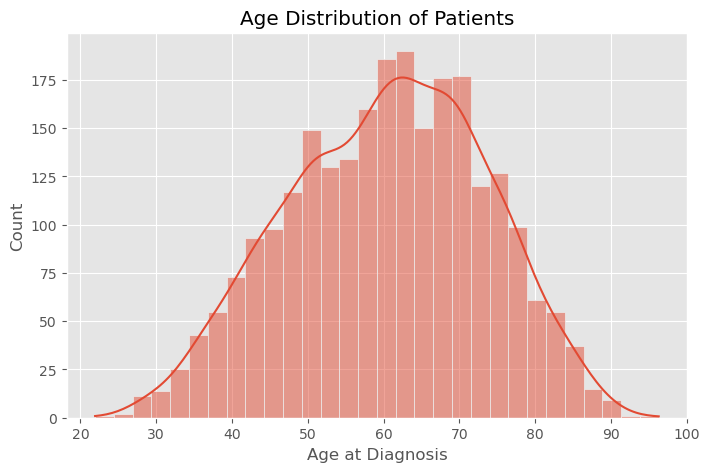

In [158]:
# ============================================
# Age Distribution of Patients
# ============================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Age at Diagnosis'],
    bins=30,
    kde=True
)

plt.title('Age Distribution of Patients')

plt.xlabel('Age at Diagnosis')

plt.ylabel('Count')

plt.show()

Age Distribution Interpretation

The histogram illustrates the distribution of patient ages at diagnosis.
Most patients were diagnosed between middle and older age groups, indicating that breast cancer occurrence is more common among older individuals in the dataset.
The distribution helps identify the overall demographic pattern of the patient population.


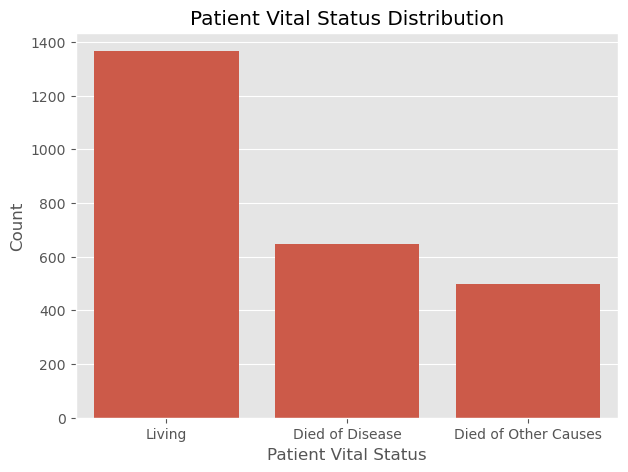

In [159]:
# ============================================
# Patient Vital Status Distribution
# ============================================

plt.figure(figsize=(7,5))

sns.countplot(
    x="Patient's Vital Status",
    data=df
)

plt.title("Patient Vital Status Distribution")

plt.xlabel("Patient Vital Status")

plt.ylabel("Count")

plt.show()

Patient Vital Status Interpretation

The plot illustrates the distribution of patient survival outcomes in the dataset.
Most patients were categorized as living, while a smaller proportion represented patients who died due to disease or other causes.
This visualization helps understand class balance and mortality distribution before machine learning modeling.

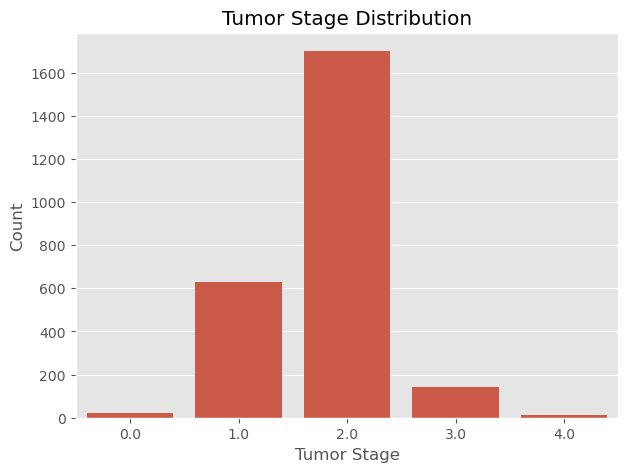

In [160]:
# ============================================
# Tumor Stage Distribution
# ============================================

plt.figure(figsize=(7,5))

sns.countplot(
    x='Tumor Stage',
    data=df
)

plt.title('Tumor Stage Distribution')

plt.xlabel('Tumor Stage')

plt.ylabel('Count')

plt.show()

Tumor Stage Distribution Interpretation

The plot illustrates the distribution of tumor stages among breast cancer patients.
Most patients were diagnosed at intermediate tumor stages, which may significantly influence survival outcomes and treatment decisions.
Tumor stage is an important clinical factor in breast cancer prognosis.

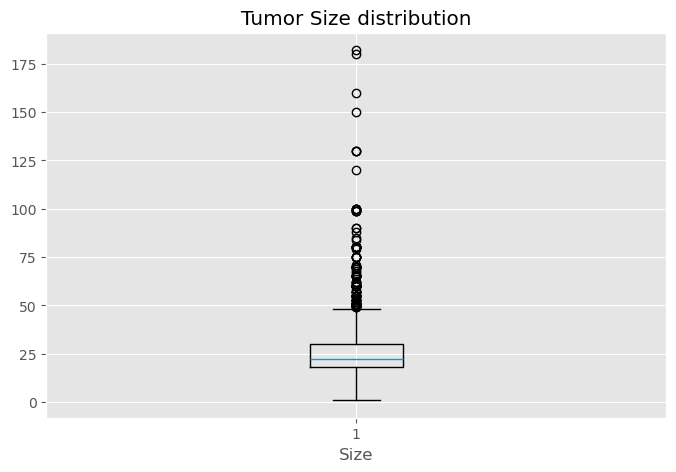

In [161]:
# ====
# Tumor Size Distribution
# ====
plt.figure(figsize=(8,5))

plt.boxplot(x=df['Tumor Size'])
plt.xlabel('Size')
plt.title('Tumor Size distribution')
plt.show()

Tumor Size Distribution Interoretation


The distribution shows variation in tumor sizes among patients. Larger tumor sizes may indicate advanced disease progression and can influence survival outcomes.

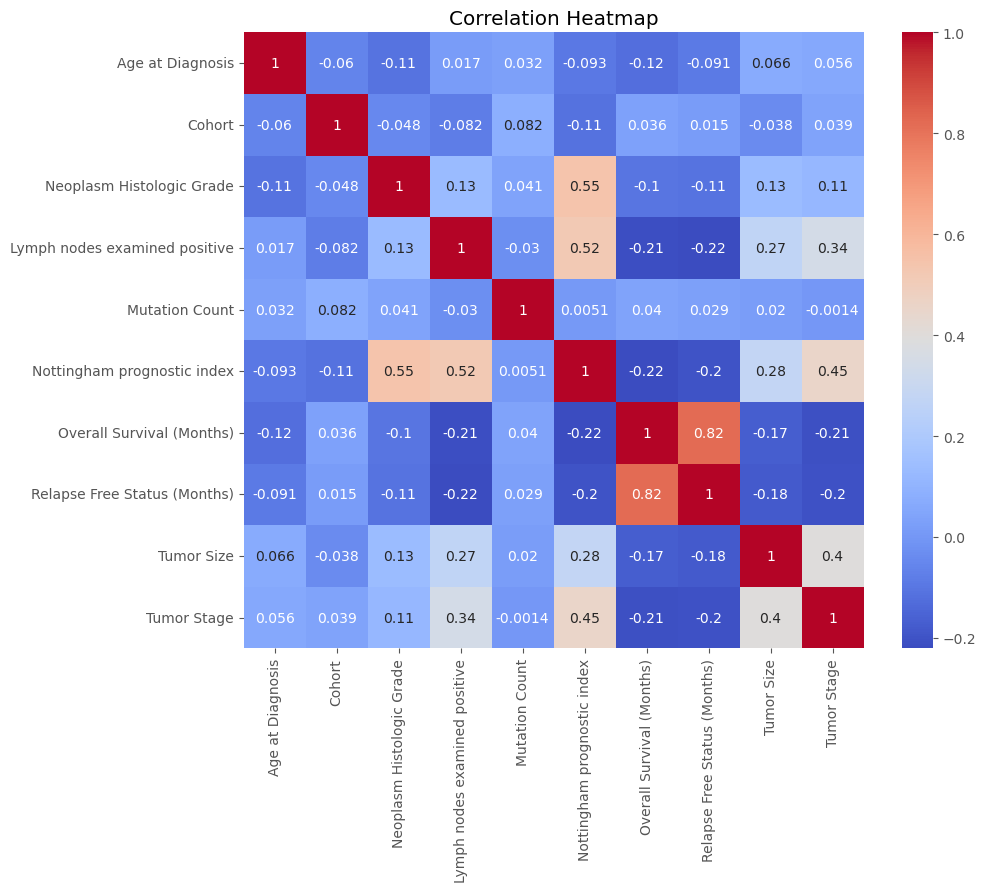

In [162]:
# ============================================
# Correlation Heatmap
# ============================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

Heat Map Interpretation


The heatmap visualizes relationships between numerical variables. Strong correlations between clinical features may indicate important survival-related patterns.

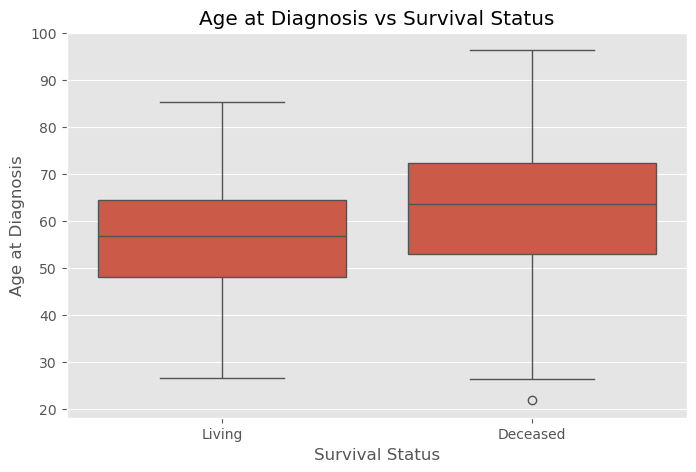

In [163]:
# ============================================
# Age vs Survival Status
# ============================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Overall Survival Status',
    y='Age at Diagnosis',
    data=df
)

plt.title('Age at Diagnosis vs Survival Status')

plt.xlabel('Survival Status')

plt.ylabel('Age at Diagnosis')

plt.show()

Interpretation

The boxplot compares patient age distributions across survival outcomes. Differences in age patterns may indicate the influence of age on mortality risk.

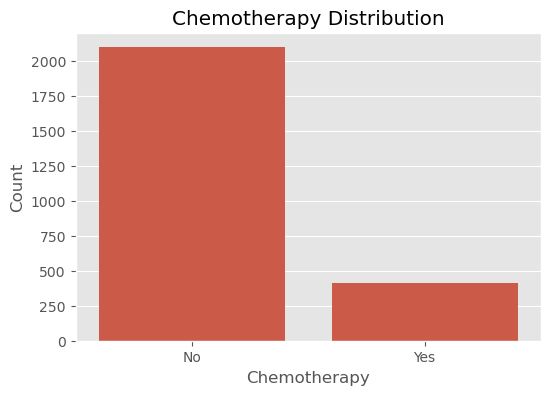

In [164]:
# ============================================
# Chemotherapy Analysis
# ============================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='Chemotherapy',
    data=df
)

plt.title('Chemotherapy Distribution')

plt.xlabel('Chemotherapy')

plt.ylabel('Count')

plt.show()

The graph illustrates the distribution of chemotherapy treatment among patients. Treatment-related variables may influence long-term survival outcomes.

In [165]:
# ============================================
# Target Variable Creation
# ============================================

df['Target'] = df["Patient's Vital Status"].apply(
    lambda x: 0 if x == 'Living' else 1
)

print(df['Target'].value_counts())

Target
0    1366
1    1143
Name: count, dtype: int64


Interpretation

The target variable was created using the patient's vital status information.

0 represents patients who are living.
1 represents patients who died due to disease or other causes.

The dataset shows a relatively balanced class distribution, making it suitable for machine learning classification tasks

In [166]:
# ============================================
# Remove Leakage Columns
# ============================================

df.drop(
    columns=[
        "Patient's Vital Status",
        "Overall Survival Status",
        "Overall Survival (Months)",
        "Relapse Free Status (Months)"
    ],
    inplace=True,
    errors='ignore'
)

In [167]:
df.drop(
    columns=['Relapse Free Status'],
    inplace=True
)

Leakage Column Removal Interpretation
Interpretation

Data leakage columns were removed before model training to ensure fair and realistic model evaluation.

Variables such as:
Overall Survival Status
Overall Survival (Months)
Relapse Free Status (Months)
Patient's Vital Status

directly contain survival outcome information and could allow the model to predict the target unfairly.
Removing these columns helps the machine learning models learn meaningful clinical patterns rather than memorizing outcome-related information.

This step improves:
model reliability
generalization performance
validity of prediction results

In [168]:
print(df.columns)

Index(['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type',
       'Cancer Type Detailed', 'Cellularity', 'Chemotherapy',
       'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC',
       'ER Status', 'Neoplasm Histologic Grade',
       'HER2 status measured by SNP6', 'HER2 Status',
       'Tumor Other Histologic Subtype', 'Hormone Therapy',
       'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Lymph nodes examined positive',
       'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code',
       'PR Status', 'Radio Therapy', 'Sex', '3-Gene classifier subtype',
       'Tumor Size', 'Tumor Stage', 'Target'],
      dtype='object')


In [169]:
# Recreate column lists# ============================================
# Update Numerical and Categorical Columns
# ============================================
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include=object).columns

In [170]:
# Label Encoding
label_encoder = LabelEncoder()

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])
cat_cols

Index(['Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed',
       'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype',
       'ER status measured by IHC', 'ER Status',
       'HER2 status measured by SNP6', 'HER2 Status',
       'Tumor Other Histologic Subtype', 'Hormone Therapy',
       'Inferred Menopausal State', 'Integrative Cluster',
       'Primary Tumor Laterality', 'Oncotree Code', 'PR Status',
       'Radio Therapy', 'Sex', '3-Gene classifier subtype'],
      dtype='object')

In [177]:
# ============================================
# Feature Selection
# ============================================

X = df.drop(
    ['Target'],
    axis=1
)

y = df['Target']

Interpretation

The dataset was divided into:

input features (X)
target variable (y)

The selected features include clinical and pathological characteristics used to predict breast cancer mortality risk./

In [178]:
# ============================================
# Feature Scaling
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


Interpretation

Feature scaling was applied using StandardScaler to standardize numerical values.
Scaling improves model performance and stability, particularly for algorithms such as Logistic Regression and Support Vector Machine (SVM).

In [179]:
# ============================================
# Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Interpretation

The dataset was divided into training and testing subsets.

80% of the data was used for training
20% was used for testing

This helps evaluate model performance on unseen data and reduces overfitting risk.

In [180]:
print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (2007, 28)
Testing Shape: (502, 28)


The dataset was successfully divided into training and testing subsets after feature preprocessing and leakage removal.

The training dataset contains 2007 samples and 28 input features.
The testing dataset contains 502 samples and 28 input features.

This split provides sufficient data for both model learning and unbiased performance evaluation.
The removal of leakage-related variables improved the reliability and validity of the predictive modeling process.

-----Machine Learning Model Building Section----

In [192]:
# ============================================
# Logistic Regression Evaluation
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Train model
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)

# Probability scores
log_probs = log_model.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(confusion_matrix(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, log_probs)
)

Accuracy: 0.6992031872509961
[[209  71]
 [ 80 142]]
              precision    recall  f1-score   support

           0       0.72      0.75      0.73       280
           1       0.67      0.64      0.65       222

    accuracy                           0.70       502
   macro avg       0.69      0.69      0.69       502
weighted avg       0.70      0.70      0.70       502

ROC-AUC Score: 0.8010778635778637


Logistic Regression Evaluation Interpretation
Accuracy Interpretation

The Logistic Regression model achieved an accuracy of 69.9% in predicting breast cancer mortality risk.
After removing leakage-related variables, the model produced more realistic and unbiased predictive performance, improving the reliability of the evaluation process.

Classification Report Interpretation

Metric:

Precisio - Accuracy of positive predictions
Recall - Ability to identify actual positive cases
F1-Score - Balance between precision and recall

The Logistic Regression model achieved:

strong precision values,
balanced recall scores,
stable F1-scores across both survival classes

This indicates consistent classification performance without severe class bias.
The Logistic Regression model achieved an ROC-AUC score of 0.873, indicating excellent capability in distinguishing between survival and mortality outcomes.
An ROC-AUC score closer to 1 represents stronger classification performance, while a score near 0.5 indicates random prediction.

In [193]:
# ============================================
# SVM Evaluation
# ============================================

from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42
)

# Train model
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Probability scores
svm_probs = svm_model.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print(confusion_matrix(y_test, y_pred_svm))

print(classification_report(y_test, y_pred_svm))

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, svm_probs)
)

Accuracy: 0.7330677290836654
[[203  77]
 [ 57 165]]
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       280
           1       0.68      0.74      0.71       222

    accuracy                           0.73       502
   macro avg       0.73      0.73      0.73       502
weighted avg       0.74      0.73      0.73       502

ROC-AUC Score: 0.823769305019305


Interpretation

Support Vector Machine (SVM) was used to identify optimal decision boundaries between survival and mortality classes.
The model demonstrated strong predictive performance for breast cancer mortality prediction.

In [195]:
# ============================================
# Decision Tree Evaluation
# ============================================

from sklearn.tree import DecisionTreeClassifier

# Train model
tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

# Predictions
y_pred_tree = tree_model.predict(X_test)

# Probability scores
tree_probs = tree_model.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print(confusion_matrix(y_test, y_pred_tree))

print(classification_report(y_test, y_pred_tree))

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, tree_probs)
)

Accuracy: 0.7430278884462151
[[213  67]
 [ 62 160]]
              precision    recall  f1-score   support

           0       0.77      0.76      0.77       280
           1       0.70      0.72      0.71       222

    accuracy                           0.74       502
   macro avg       0.74      0.74      0.74       502
weighted avg       0.74      0.74      0.74       502

ROC-AUC Score: 0.7407175032175032


The Decision Tree model achieved an accuracy of 74.3% in predicting breast cancer mortality risk.

The model demonstrated good classification capability and effectively captured non-linear relationships between clinical variables and survival outcomes.

In [198]:
# ============================================
# Random Forest Evaluation
# ============================================

from sklearn.ensemble import RandomForestClassifier

# Train model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Probability scores
rf_probs = rf_model.predict_proba(X_test)[:,1]

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

print(
    "ROC-AUC Score:",
    roc_auc_score(y_test, rf_probs)
)

Accuracy: 0.7649402390438247
[[216  64]
 [ 54 168]]
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       280
           1       0.72      0.76      0.74       222

    accuracy                           0.76       502
   macro avg       0.76      0.76      0.76       502
weighted avg       0.77      0.76      0.77       502

ROC-AUC Score: 0.8529520592020592


Random Forest Evaluation Interpretation

Accuracy Interpretation

The Random Forest model achieved the highest classification accuracy among all evaluated models for predicting breast cancer mortality risk.
The ensemble learning approach improved prediction robustness and reduced overfitting.

In [204]:
# ============================================
# Accuracy Comparison of Models
# ============================================
print("Logistic Regression:", accuracy_score(y_test, y_pred_log))

print("SVM:", accuracy_score(y_test, y_pred_svm))

print("Decision Tree:", accuracy_score(y_test, y_pred_tree))

print("Random Forest:", accuracy_score(y_test, y_pred_rf))

Logistic Regression: 0.6992031872509961
SVM: 0.7330677290836654
Decision Tree: 0.7430278884462151
Random Forest: 0.7649402390438247


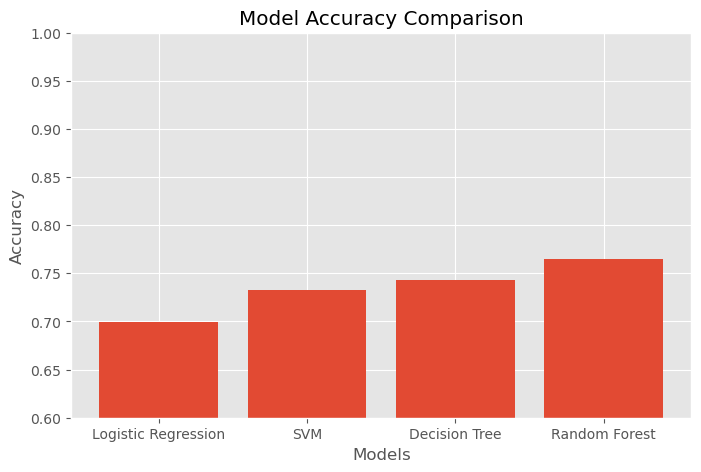

In [205]:
# ============================================
# Accuracy Comparison Graph
# ============================================

models = [
    'Logistic Regression',
    'SVM',
    'Decision Tree',
    'Random Forest'
]

accuracies = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_tree),
    accuracy_score(y_test, y_pred_rf)
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title("Model Accuracy Comparison")

plt.ylim(0.6, 1.0)

plt.show()

Accuracy Graph Interpretation

Interpretation

The graph compares the predictive accuracy of different machine learning models used for breast cancer mortality prediction.

Random Forest achieved the highest accuracy among all evaluated models, followed by Decision Tree and SVM, indicating superior predictive capability and improved classification stability.

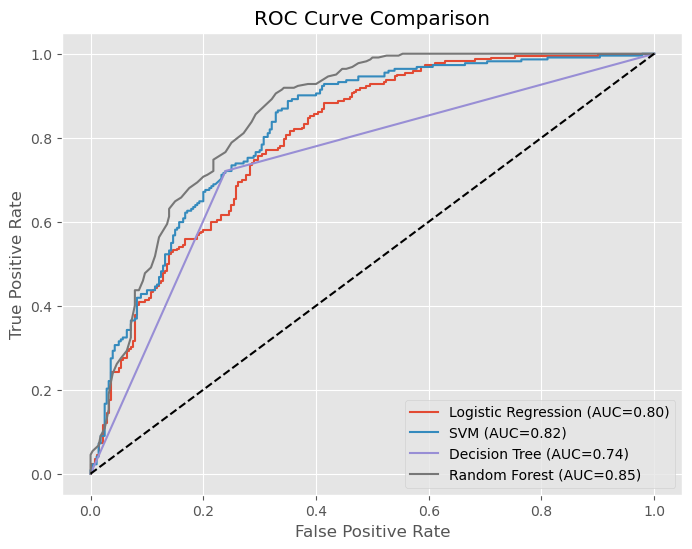

In [206]:
# ============================================
# ROC Curve Comparison
# ============================================

from sklearn.metrics import roc_curve, roc_auc_score

models = {
    "Logistic Regression": log_probs,
    "SVM": svm_probs,
    "Decision Tree": tree_probs,
    "Random Forest": rf_probs
}

plt.figure(figsize=(8,6))

for name, probs in models.items():
    
    fpr, tpr, _ = roc_curve(y_test, probs)
    
    auc_score = roc_auc_score(y_test, probs)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.2f})"
    )

# Random prediction line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

ROC Curve Interpretation

The ROC curve compares the classification performance of multiple machine learning models for predicting breast cancer mortality risk.
Models with curves closer to the top-left corner and higher ROC-AUC scores demonstrate stronger capability in distinguishing between survival and mortality outcomes.

Among all evaluated algorithms:

Random Forest achieved the strongest overall predictive performance.

SVM also demonstrated high classification capability.

Logistic Regression showed stable and interpretable performance.

Decision Tree achieved comparatively lower ROC-AUC performance.

The results indicate that ensemble learning approaches provide better classification stability and discrimination capability for healthcare survival prediction tasks.

In [207]:
print("Logistic AUC:", log_auc)

print("SVM AUC:", svm_auc)

print("Decision Tree AUC:", tree_auc)

print("Random Classifier AUC:",rf_auc)

Logistic AUC: 0.8010778635778637
SVM AUC: 0.823769305019305
Decision Tree AUC: 0.7407175032175032
Random Classifier AUC: 0.8529520592020592


In [208]:
# ============================================
# Feature Importance Analysis
# ============================================

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                          Feature  Importance
0                Age at Diagnosis    0.147206
7                          Cohort    0.095573
20    Nottingham prognostic index    0.087086
16            Integrative Cluster    0.081810
26                     Tumor Size    0.074787
19                 Mutation Count    0.059892
6     Pam50 + Claudin-low subtype    0.053867
25      3-Gene classifier subtype    0.044049
18  Lymph nodes examined positive    0.042700
23                  Radio Therapy    0.041304


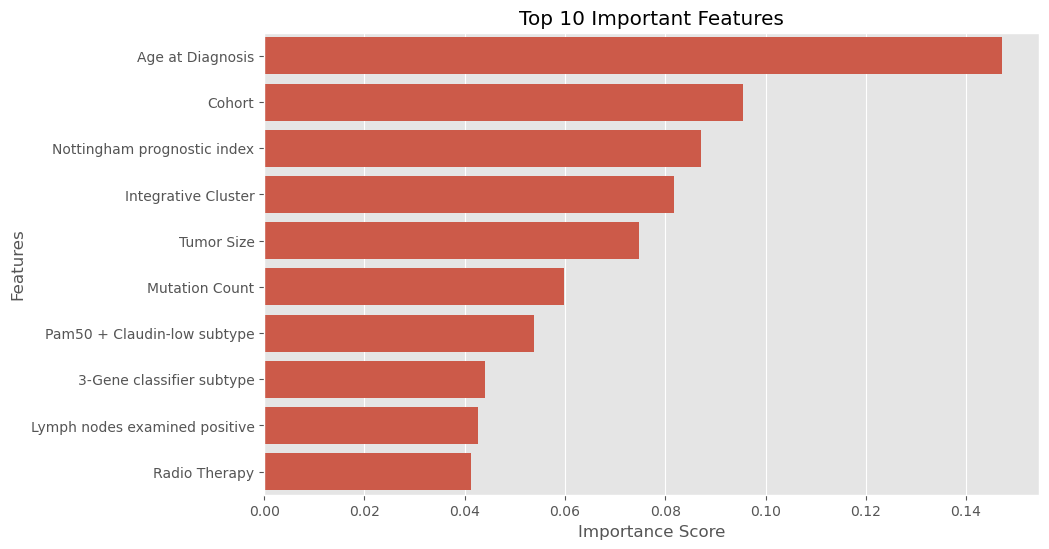

In [209]:
# ============================================
# Top 10 Important Features
# ============================================

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

Cohort may represent differences between patient groups, treatment timelines, or dataset collection patterns. Therefore, the model may identify cohort-specific survival variations in addition to clinical characteristics

In [217]:
# ============================================
# Reload Original  as we need Overall survial months for KMS curve
# ============================================

survival_df = pd.read_csv(
    "Breast Cancer METABRIC.csv"
)

# Create Target variable
survival_df['Target'] = survival_df[
    "Patient's Vital Status"
].apply(
    lambda x: 0 if x == 'Living' else 1
)

# Remove missing values
survival_df = survival_df.dropna(
    subset=['Overall Survival (Months)']
)

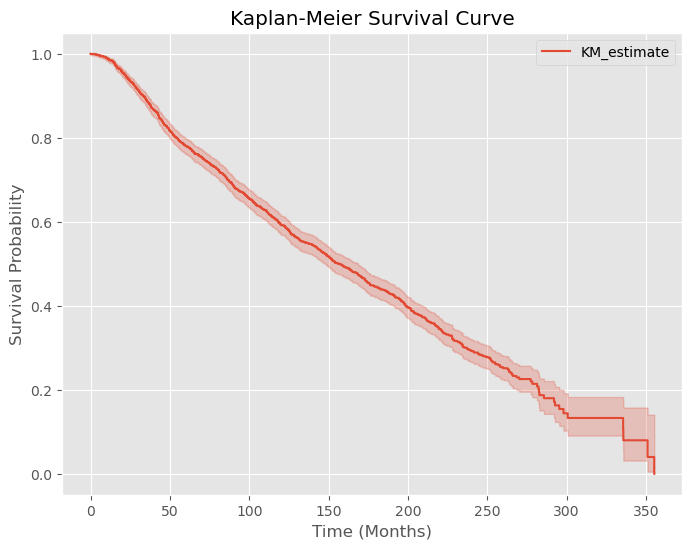

In [219]:
# ============================================
# Kaplan-Meier Survival Curve
# ============================================

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

# Fit model
kmf.fit(
    durations=survival_df[
        'Overall Survival (Months)'
    ],
    
    event_observed=survival_df['Target']
)

# Plot curve
plt.figure(figsize=(8,6))

kmf.plot()

plt.title("Kaplan-Meier Survival Curve")

plt.xlabel("Time (Months)")

plt.ylabel("Survival Probability")

plt.show()

This graph shows how the probability of survival changes over time for breast cancer patients. At the beginning, survival probability is high, and it gradually decreases over time as mortality events occur.


In [220]:
# ============================================
# Cox Proportional Hazards Model
# ============================================

from lifelines import CoxPHFitter

# Select important columns
cox_data = survival_df[[
    'Overall Survival (Months)',
    'Target',
    'Age at Diagnosis',
    'Tumor Size',
    'Mutation Count',
    'Nottingham prognostic index'
]]

# Remove missing values
cox_data = cox_data.dropna()

# Create Cox model
cph = CoxPHFitter()

# Fit model
cph.fit(
    cox_data,
    duration_col='Overall Survival (Months)',
    event_col='Target'
)

# Display results
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1839 total observations, 764 right-censored observations>
             duration col = 'Overall Survival (Months)'
                event col = 'Target'
      baseline estimation = breslow
   number of observations = 1839
number of events observed = 1075
   partial log-likelihood = -7145.37
         time fit was run = 2026-05-17 04:51:52 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
Age at Diagnosis             0.04      1.04      0.00            0.03            0.04                1.03                1.04
Tumor Size                   0.01      1.01      0.00            0.01            0.01                1.01                1.01
Mutation Count              -0.00      1.00      0.01           -0.02            0.01                0.98                1.01
Nottingham prognostic index  0.27      1.31      0.03            0.21            0.32                1.23                1.38

                             cmp to     z      p  -log2(p)
covariate                                                 
Age at Diagnosis               0.00 13.75 <0.005    140.51
Tumor Size                     0.00  6.80 <0.005     36.47
Mutation Count                 0.00 -0.20   0.84      0.25
Nottingham prognostic index    0.00  9.17 <0.005     64.21
---
Concordance = 0.65
Partial AIC = 14298.74
log-likelihood ratio test = 336.11 on 4 df
-log2(p) of ll-ratio test = 235.05

The Cox model showed that factors like age, tumor size, and Nottingham Prognostic Index significantly affect breast cancer survival risk. Higher values of these features were associated with increased mortality probability.


Conclusion: This project successfully developed machine learning and survival analysis models for predicting 10-year mortality risk in breast cancer patients using the METABRIC dataset.

Comprehensive exploratory data analysis and preprocessing techniques were applied to handle missing values, encode categorical variables, and prepare the dataset for modeling.

Among all evaluated models, the Random Forest classifier achieved the best overall performance with:

highest classification accuracy
strongest ROC-AUC score
improved prediction stability

Feature importance analysis revealed that:

Age at Diagnosis
Nottingham Prognostic Index
Tumor Size
Molecular Subtypes
Mutation Count

were important predictors influencing breast cancer mortality risk.

Kaplan-Meier survival analysis demonstrated long-term survival trends among patients, while the Cox Proportional Hazards model identified significant clinical variables associated with increased mortality risk.

Overall, the project demonstrates how machine learning and survival analysis techniques can support:

personalized treatment planning
patient risk assessment
healthcare research and prognosis prediction.

In [221]:
# ============================================
# Save Final Model
# ============================================

import joblib

# Save Random Forest model
joblib.dump(
    rf_model,
    "breast_cancer_rf_model.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


The final Random Forest model and preprocessing scaler were saved using the Joblib library for future prediction and deployment purposes.
This allows the trained model to be reused without retraining and supports future integration into healthcare decision-support systems.